# Análise exploratória — voos nos EUA

Dados do [Flight Prices](https://www.kaggle.com/datasets/dilwong/flightprices) (pesquisas no Expedia entre abril e outubro de 2022),
reduzidos aos voos diretos com `filter-itineraries`. Os preços estão em dólares.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from flight_prices.itineraries import add_date_features, load_itineraries

sns.set_theme(style="whitegrid", palette="husl")
pd.set_option("display.max_columns", None)

DATA_DIR = Path("../data")

In [2]:
df = add_date_features(load_itineraries(DATA_DIR / "voos_filtrados.csv"))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22066888 entries, 0 to 22066887
Data columns (total 11 columns):
 #   Column               Dtype         
---  ------               -----         
 0   searchDate           datetime64[us]
 1   flightDate           datetime64[us]
 2   startingAirport      category      
 3   destinationAirport   category      
 4   totalFare            float64       
 5   segmentsAirlineName  category      
 6   dias_ate_voo         int16         
 7   mes_voo              int8          
 8   dia_semana_voo       int8          
 9   mes_pesquisa         int8          
 10  dia_semana_pesquisa  int8          
dtypes: category(3), datetime64[us](2), float64(1), int16(1), int8(4)
memory usage: 694.5 MB


In [3]:
df.describe()

,searchDate,flightDate,totalFare,dias_ate_voo,mes_voo,dia_semana_voo,mes_pesquisa,dia_semana_pesquisa
count,22066888,22066888,2.206689e+07,2.206689e+07,2.206689e+07,2.206689e+07,2.206689e+07,2.206689e+07
mean,2022-07-10 03:30:19.761518,2022-08-06 10:08:50.110888,2.511486e+02,2.727674e+01,7.693867e+00,2.945452e+00,6.795987e+00,3.094477e+00
min,2022-04-16 00:00:00,2022-04-17 00:00:00,1.959000e+01,1.000000e+00,4.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00
25%,2022-06-01 00:00:00,2022-06-27 00:00:00,1.486000e+02,1.300000e+01,6.000000e+00,1.000000e+00,6.000000e+00,1.000000e+00
50%,2022-07-10 00:00:00,2022-08-09 00:00:00,2.156000e+02,2.600000e+01,8.000000e+00,3.000000e+00,7.000000e+00,3.000000e+00
75%,2022-08-18 00:00:00,2022-09-15 00:00:00,3.136000e+02,4.000000e+01,9.000000e+00,5.000000e+00,8.000000e+00,5.000000e+00
max,2022-10-05 00:00:00,2022-11-19 00:00:00,4.923600e+03,6.000000e+01,1.100000e+01,6.000000e+00,1.000000e+01,6.000000e+00
std,NaN,NaN,1.644708e+02,1.626501e+01,1.643459e+00,1.994668e+00,1.616541e+00,1.982562e+00


## Distribuição dos preços

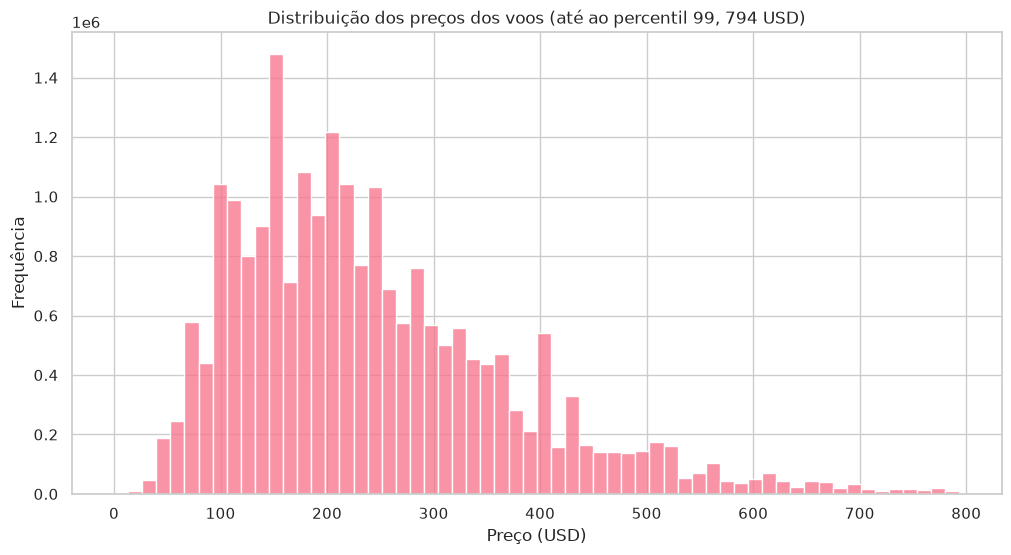

In [4]:
p99 = df["totalFare"].quantile(0.99)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="totalFare", bins=60, binrange=(0, p99))
plt.title(f"Distribuição dos preços dos voos (até ao percentil 99, {p99:.0f} USD)")
plt.xlabel("Preço (USD)")
plt.ylabel("Frequência")
plt.show()

## Preço por companhia aérea

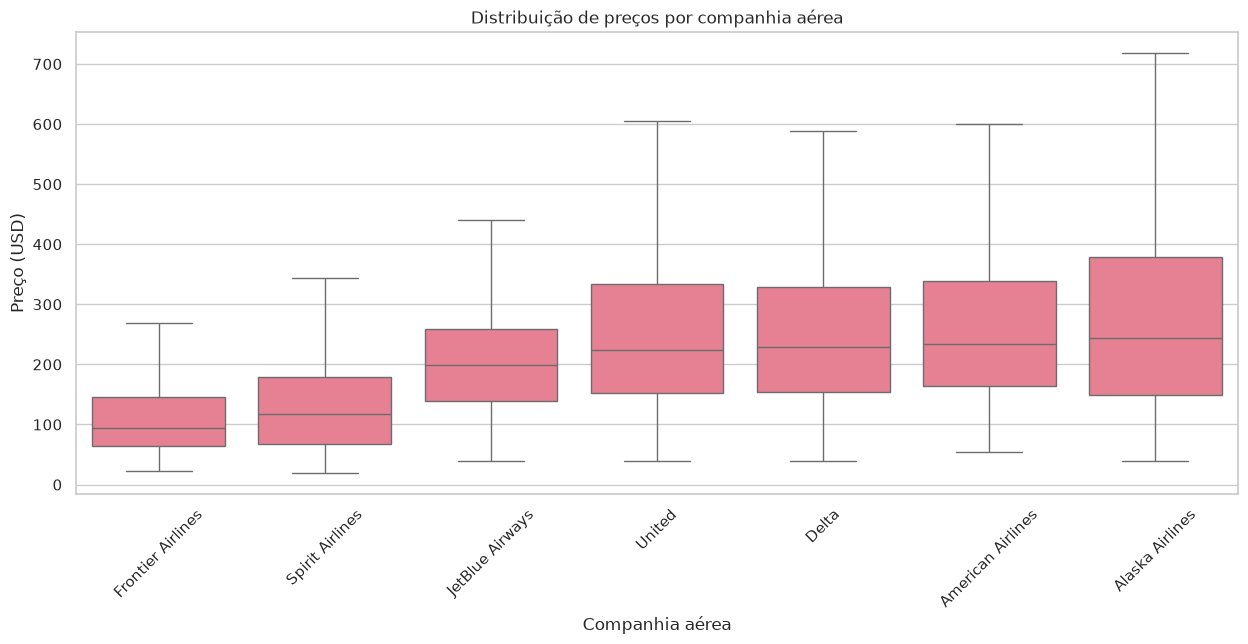

In [5]:
airline_order = df.groupby("segmentsAirlineName", observed=True)["totalFare"].median().sort_values().index

plt.figure(figsize=(15, 6))
sns.boxplot(data=df, x="segmentsAirlineName", y="totalFare", order=airline_order, showfliers=False)
plt.xticks(rotation=45)
plt.title("Distribuição de preços por companhia aérea")
plt.xlabel("Companhia aérea")
plt.ylabel("Preço (USD)")
plt.show()

## Rotas mais frequentes

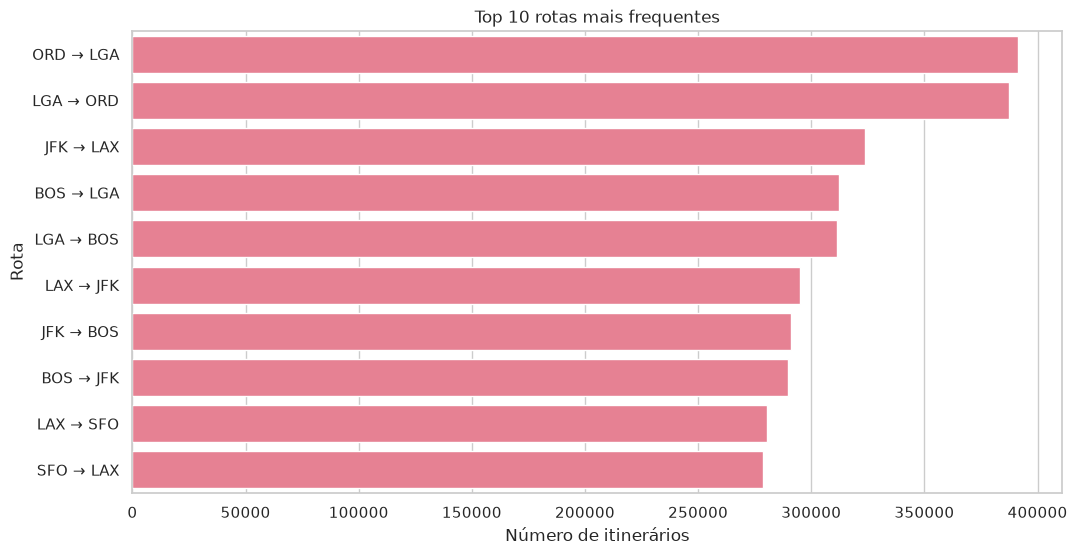

In [6]:
top_routes = (
    df.groupby(["startingAirport", "destinationAirport"], observed=True)
    .size()
    .nlargest(10)
    .rename("itinerarios")
    .reset_index()
)
top_routes["rota"] = top_routes["startingAirport"].astype(str) + " → " + top_routes["destinationAirport"].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_routes, x="itinerarios", y="rota")
plt.title("Top 10 rotas mais frequentes")
plt.xlabel("Número de itinerários")
plt.ylabel("Rota")
plt.show()

## Antecedência da compra

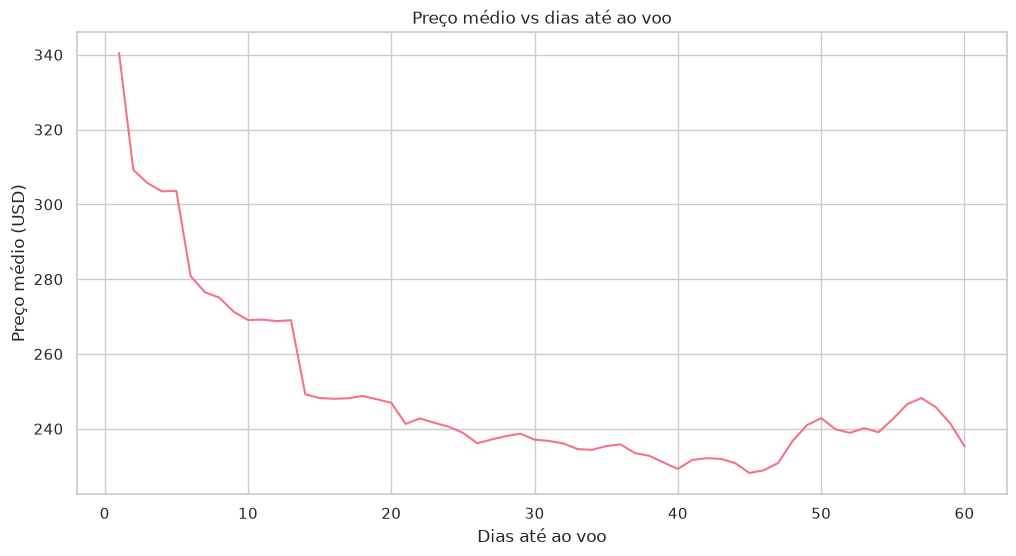

In [7]:
plt.figure(figsize=(12, 6))
df.groupby("dias_ate_voo")["totalFare"].mean().plot()
plt.title("Preço médio vs dias até ao voo")
plt.xlabel("Dias até ao voo")
plt.ylabel("Preço médio (USD)")
plt.show()

## Mês da pesquisa vs mês do voo

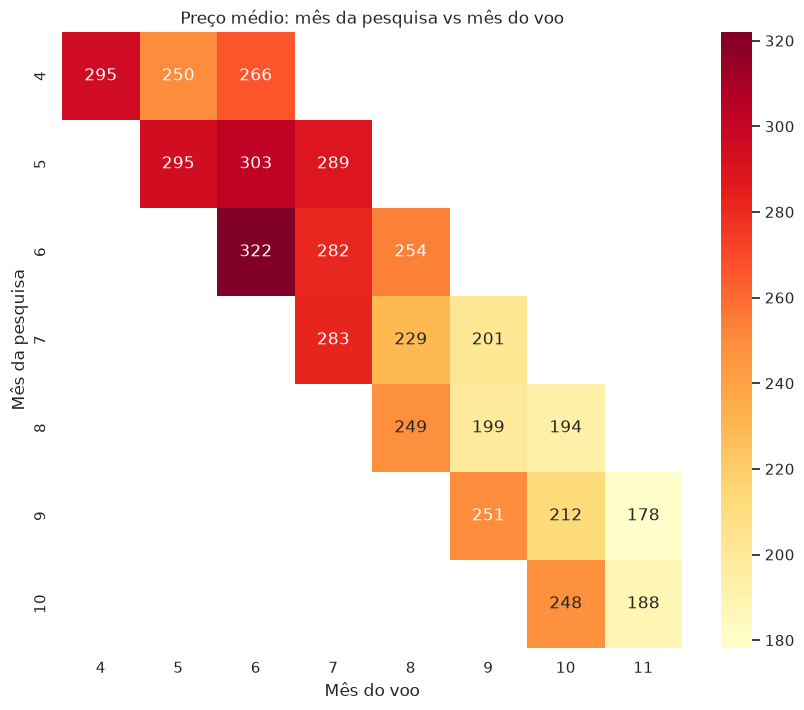

In [8]:
fare_by_month = df.pivot_table(values="totalFare", index="mes_pesquisa", columns="mes_voo", aggfunc="mean")

plt.figure(figsize=(10, 8))
ax = sns.heatmap(fare_by_month, annot=True, fmt=".0f", cmap="YlOrRd")
ax.grid(False)
plt.title("Preço médio: mês da pesquisa vs mês do voo")
plt.xlabel("Mês do voo")
plt.ylabel("Mês da pesquisa")
plt.show()

## Resumo

In [9]:
pd.Series(
    {
        "Preço médio (USD)": df["totalFare"].mean(),
        "Preço mediano (USD)": df["totalFare"].median(),
        "Antecedência média (dias)": df["dias_ate_voo"].mean(),
    }
).round(2)

Preço médio (USD)            251.15
Preço mediano (USD)          215.60
Antecedência média (dias)     27.28
dtype: float64

In [10]:
df.loc[[df["totalFare"].idxmax(), df["totalFare"].idxmin()]]

,searchDate,flightDate,startingAirport,destinationAirport,totalFare,segmentsAirlineName,dias_ate_voo,mes_voo,dia_semana_voo,mes_pesquisa,dia_semana_pesquisa
18792590,2022-09-08,2022-09-10,BOS,LAX,4923.60,American Airlines,2,9,5,9,3
13542804,2022-07-26,2022-09-03,LAX,OAK,19.59,Spirit Airlines,39,9,5,7,1
